In [ ]:
from sae_lens import SAE
from sae_java_bug.sparse_autoencoders.schemas import KODCODE_LLAMA_3_2_1B_CONFIG

cfg = KODCODE_LLAMA_3_2_1B_CONFIG

# Load SAE from local disk
sae = SAE.load_from_disk(cfg.sae_path(layer_index=0))
print(sae)

ImportError: cannot import name 'KODCODE_LLAMA_3_2_1B_CONFIG' from 'sae_java_bug.sparse_autoencoders.schemas' (/Users/rmelo/Documents/GitHub/SAE-Java-Bug-Detection/sae_java_bug/sparse_autoencoders/schemas.py)

In [1]:
from dataclasses import dataclass

from tqdm import tqdm

import orjson
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import accuracy_score
from torch.utils.data import DataLoader, TensorDataset, random_split
from tqdm import tqdm, trange

from sae_java_bug.logger import logger
from sae_java_bug.sparse_autoencoders.utils import get_device


@dataclass
class VulnerabilityData:
    vulnerable: torch.Tensor
    secure: torch.Tensor


/Users/rmelo/miniconda3/envs/demeanor/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [9]:
import glob
import orjson
import torch
from tqdm import tqdm
from sae_java_bug.sparse_autoencoders.sae_exploration import ActivationsSchema

from sae_java_bug.logger import logger
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
import numpy as np
from typing import Dict, Tuple
from sklearn.model_selection import KFold

class MLP(nn.Module):
    def __init__(
        self, input_dim, output_dim=2, hidden=(128, 64), dropout=0.3, use_bn=True
    ):
        super().__init__()
        h1, h2 = hidden
        self.use_bn = use_bn

        self.fc1 = nn.Linear(input_dim, h1)
        self.bn1 = nn.BatchNorm1d(h1) if use_bn else nn.Identity()
        self.fc2 = nn.Linear(h1, h2)
        self.bn2 = nn.BatchNorm1d(h2) if use_bn else nn.Identity()
        self.fc3 = nn.Linear(h2, output_dim)
        self.drop = nn.Dropout(dropout)

    def forward(self, x):
        x = self.fc1(x)
        x = self.bn1(x)
        x = F.relu(x)
        x = self.drop(x)

        x = self.fc2(x)
        x = self.bn2(x)
        x = F.relu(x)
        x = self.drop(x)

        x = self.fc3(x)  # logits
        return x

def evaluate(loader, model, device=get_device(verbose=False)):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            preds = logits.argmax(dim=1)
            all_preds.append(preds.cpu())
            all_labels.append(y.cpu())
    y_true = torch.cat(all_labels)
    y_pred = torch.cat(all_preds)
    return accuracy_score(y_true, y_pred), y_true, y_pred

def train_small_mlp_kfold(class_negative: torch.Tensor, class_positive: torch.Tensor, k=5):

    # Create labels
    vuln_labels = torch.ones(class_positive.size(0), dtype=torch.float32)
    safe_labels = torch.zeros(class_negative.size(0), dtype=torch.float32)

    all_features = torch.cat((class_positive, class_negative), dim=0).float()
    all_labels = torch.cat((vuln_labels, safe_labels), dim=0).long()

    # print("All Features Shape:", all_features.shape)
    # print("All Labels Shape:", all_labels.shape)

    dataset = TensorDataset(all_features, all_labels)

    # Initialize KFold
    kf = KFold(n_splits=k, shuffle=True, random_state=42)

    fold = 1
    fold_acc = []

    for train_idx, test_idx in kf.split(all_features):

        # print(f"\n===== Fold {fold}/{k} =====")
        fold += 1

        train_subset = torch.utils.data.Subset(dataset, train_idx)
        test_subset  = torch.utils.data.Subset(dataset, test_idx)

        train_loader = DataLoader(train_subset, batch_size=32, shuffle=True, drop_last=True)
        test_loader  = DataLoader(test_subset, batch_size=1000, shuffle=False, drop_last=False)

        # new model per fold
        model = MLP(input_dim=all_features.size(1)).to(device)
        # activate gradients
        model.train()
        torch.set_grad_enabled(True)
        optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

        num_epochs = 50  # often fewer needed

        for epoch in range(num_epochs):
            model.train()
            for x_batch, y_batch in train_loader:
                x_batch, y_batch = x_batch.to(device), y_batch.to(device)

                optimizer.zero_grad()
                logits = model(x_batch)
                loss = F.cross_entropy(logits, y_batch)
                loss.backward()
                optimizer.step()

        # evaluate this fold
        acc, _, _ = evaluate(test_loader, model, device)
        fold_acc.append(acc)

    #     print(f"Fold Test Accuracy: {acc:.4f}")

    # print("\n===== K-Fold Results =====")
    # print(f"Fold Accuracies: {fold_acc}")
    # print(f"Mean Accuracy: {sum(fold_acc)/len(fold_acc):.4f}")

    return sum(fold_acc)/len(fold_acc)


device = get_device(verbose=True)

layer_scores = {}
RUN_ID = "run_20260127_044329"

files = sorted(glob.glob(f"../artifacts/activations/{RUN_ID}/activations_layer_*"), key=lambda x: int(x.split("layer_")[1].split("_")[0]))

@dataclass
class VulnerabilityData:
    vulnerable: torch.Tensor
    secure: torch.Tensor


def compute_lda_fisher_scores(secure_features: torch.Tensor, vulnerable_features: torch.Tensor) -> float:
    # Create labels
    vuln_labels = torch.ones(vulnerable_features.size(0), dtype=torch.float32)
    safe_labels = torch.zeros(secure_features.size(0), dtype=torch.float32)
    all_features = torch.cat((vulnerable_features, secure_features), dim=0).float()
    all_labels = torch.cat((vuln_labels, safe_labels), dim=0).long()

    # LDA — build dataset for layer
    X = all_features.numpy()
    y = all_labels.numpy()

    # Train LDA
    lda = LinearDiscriminantAnalysis(n_components=1)
    proj = lda.fit_transform(X, y)

    vuln_proj = proj[: len(vulnerable_features)]
    safe_proj = proj[len(vulnerable_features):]

    mean_diff = vuln_proj.mean() - safe_proj.mean()
    var_sum = vuln_proj.var() + safe_proj.var()
    fisher_score = (mean_diff ** 2) / (var_sum + 1e-8)

    return float(fisher_score)


FisherScoreMap: Dict[Tuple[str, str], float] = {}
ProbingDataMap: Dict[Tuple[str, str], float] = {}
from typing import List
from collections import defaultdict

all_vulnerable_features: Dict[str, List[float]] = defaultdict(list)
all_safe_features : Dict[str, List[float]] = defaultdict(list)

for activation_file in files:
    logger.info("Processing file.", file=activation_file)

    cwe_tensor_map: Dict[str, VulnerabilityData] = {}
    vulnerable_features = torch.tensor([])
    safe_features = torch.tensor([])
    
    # Loads activations.
    with open(activation_file, "r") as f: 
        for line in tqdm(f, desc="Loading", unit=" lines", total=2500):
            try:
                data = orjson.loads(line)
            except orjson.JSONDecodeError as e:
                logger.error(f"JSON decoding error: {e}")
                # skip to the next file
                break
            
            cwe = data["cwe"]
            if cwe not in cwe_tensor_map:
                cwe_tensor_map[cwe] = VulnerabilityData(
                    vulnerable=torch.tensor([]),
                    secure=torch.tensor([]),
                )

            activations = ActivationsSchema(**data)
            vuln_tensor = torch.tensor(activations.vulnerable)
            safe_tensor = torch.tensor(activations.secure)


            vulnerable_features = torch.cat(
                (vulnerable_features, vuln_tensor.unsqueeze(0)), dim=0
            )
            safe_features = torch.cat((safe_features, safe_tensor.unsqueeze(0)), dim=0)
            

            cwe_tensor_map[cwe] = VulnerabilityData(
                vulnerable=torch.cat(
                    (cwe_tensor_map[cwe].vulnerable, vuln_tensor.unsqueeze(0)), dim=0
                ),
                secure=torch.cat(
                    (cwe_tensor_map[cwe].secure, safe_tensor.unsqueeze(0)), dim=0
                ),
            )

        print("Vulnerable Features Shape:", vulnerable_features.shape , "Safe Features Shape:", safe_features.shape)
        print("CWE:", cwe, "Vulnerable Shape:", vulnerable_features.shape, "Safe Shape:", safe_features.shape)
    
        all_vulnerable_features[
            "layer_" + activation_file.split("layer_")[1].split("_")[0]
        ] = torch.tensor(vulnerable_features)
        all_safe_features[
            "layer_" + activation_file.split("layer_")[1].split("_")[0]
        ]= torch.tensor(safe_features)
        

    # Save for later reuse
    layer_id = activation_file.split("layer_")[1].split("_")[0]
    torch.save(vulnerable_features, f"../artifacts/activations/{RUN_ID}/vulnerable_layer_{layer_id}.pt")
    torch.save(safe_features, f"../artifacts/activations/{RUN_ID}/safe_layer_{layer_id}.pt")


    # for key, data in tqdm(cwe_tensor_map.items()):
    #     # Compute LDA Fisher Score for this layer and CWE
    #     fisher_score = compute_lda_fisher_scores(data.secure, data.vulnerable)
    #     # logger.info(f"  LDA Fisher Score for CWE {key}: {fisher_score:.4f}")
    #     FisherScoreMap[(layer_id, key)] = fisher_score
    #     probe_score = train_small_mlp_kfold(data.secure, data.vulnerable, k=5)
    #     ProbingDataMap[(layer_id, key)] = probe_score


    # fisher_score = compute_lda_fisher_scores(safe_features, vulnerable_features)
    # FisherScoreMap[(layer_id, "ALL")] = fisher_score


2026-01-27 06:33:02 [info     ] Getting device.                device=mps
2026-01-27 06:33:02 [info     ] Processing file.               file=../artifacts/activations/run_20260127_044329/activations_layer_0_sae_blocks.0.hook_resid_post_component_hook_resid_post.hook_sae_acts_pre.jsonl


Loading:   8%|▊         | 200/2500 [00:03<00:45, 50.10 lines/s]

Vulnerable Features Shape: torch.Size([200, 32768]) Safe Features Shape: torch.Size([200, 32768])
CWE: dataset/ETHPy150Open AppScale/appscale/AppServer/google/appengine/api/taskqueue/taskqueue_stub.py/_Queue.VerifyIndexes Vulnerable Shape: torch.Size([200, 32768]) Safe Shape: torch.Size([200, 32768])
2026-01-27 06:33:06 [info     ] Processing file.               file=../artifacts/activations/run_20260127_044329/activations_layer_1_sae_blocks.1.hook_resid_post_component_hook_resid_post.hook_sae_acts_pre.jsonl



/var/folders/s4/2zl3nz4j225gfbx8fkbdv9sm0000gq/T/ipykernel_10328/406922222.py:215: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  ] = torch.tensor(vulnerable_features)
/var/folders/s4/2zl3nz4j225gfbx8fkbdv9sm0000gq/T/ipykernel_10328/406922222.py:218: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  ]= torch.tensor(safe_features)
Loading:   8%|▊         | 200/2500 [00:03<00:44, 51.22 lines/s]


Vulnerable Features Shape: torch.Size([200, 32768]) Safe Features Shape: torch.Size([200, 32768])
CWE: dataset/ETHPy150Open AppScale/appscale/AppServer/google/appengine/api/taskqueue/taskqueue_stub.py/_Queue.VerifyIndexes Vulnerable Shape: torch.Size([200, 32768]) Safe Shape: torch.Size([200, 32768])
2026-01-27 06:33:10 [info     ] Processing file.               file=../artifacts/activations/run_20260127_044329/activations_layer_2_sae_blocks.2.hook_resid_post_component_hook_resid_post.hook_sae_acts_pre.jsonl


...

Vulnerable Features Shape: torch.Size([0]) Safe Features Shape: torch.Size([0])
CWE: dataset/ETHPy150Open AppScale/appscale/AppServer/google/appengine/api/taskqueue/taskqueue_stub.py/_Queue.VerifyIndexes Vulnerable Shape: torch.Size([0]) Safe Shape: torch.Size([0])
2026-01-27 06:33:49 [info     ] Processing file.               file=../artifacts/activations/run_20260127_044329/activations_layer_24_sae_blocks.24.hook_resid_post_component_hook_resid_post.hook_sae_acts_pre.jsonl



Loading:   0%|          | 0/2500 [00:00<?, ? lines/s]

2026-01-27 06:33:49 [error    ] JSON decoding error: unexpected character: line 1 column 548 (char 547)


Loading:   0%|          | 0/2500 [00:00<?, ? lines/s]

Vulnerable Features Shape: torch.Size([0]) Safe Features Shape: torch.Size([0])
CWE: dataset/ETHPy150Open AppScale/appscale/AppServer/google/appengine/api/taskqueue/taskqueue_stub.py/_Queue.VerifyIndexes Vulnerable Shape: torch.Size([0]) Safe Shape: torch.Size([0])


In [ ]:
# Plot an heatmap with the layers and the CWE scores
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
# Prepare data for heatmap
heatmap_data = {}
for (layer_id, cwe), score in FisherScoreMap.items():
    if cwe not in heatmap_data:
        heatmap_data[cwe] = {}
    heatmap_data[cwe][layer_id] = score


heatmap_df = pd.DataFrame.from_dict(heatmap_data, orient='index').fillna(0)
# Sort CWE (row index)
heatmap_df.index = heatmap_df.index.astype(str)
heatmap_df = heatmap_df.sort_index(key=lambda x: x.str.extract(r'(\d+)').astype(int)[0])

# Sort layer IDs (column index)
heatmap_df = heatmap_df.reindex(sorted(heatmap_df.columns, key=int), axis=1)

plt.figure(figsize=(16, 8))
sns.heatmap(heatmap_df, annot=True, fmt="1.0f", cmap="YlGnBu")
plt.title("LDA Fisher Scores by Layer and CWE")
plt.xlabel("Layer ID")
plt.ylabel("CWE")
plt.tight_layout()
plt.show()



# Plot an heatmap with the layers and the CWE probing accuracies
# Prepare data for heatmap
heatmap_data = {}
for (layer_id, cwe), score in ProbingDataMap.items():
    if cwe not in heatmap_data:
        heatmap_data[cwe] = {}
    heatmap_data[cwe][layer_id] = score

heatmap_df = pd.DataFrame.from_dict(heatmap_data, orient='index').fillna(0)
# Sort CWE (row index)
heatmap_df.index = heatmap_df.index.astype(str)
heatmap_df = heatmap_df.sort_index(key=lambda x: x.str.extract(r'(\d+)').astype(int)[0])
# Sort layer IDs (column index)
heatmap_df = heatmap_df.reindex(sorted(heatmap_df.columns, key=int), axis=1)
plt.figure(figsize=(16, 8))
sns.heatmap(heatmap_df, annot=True, fmt=".2f", cmap="YlGnBu")
plt.title("Probing Accuracies by Layer and CWE")
plt.xlabel("Layer ID")
plt.ylabel("CWE")
plt.tight_layout()
plt.show()

In [ ]:
files = sorted(glob.glob(f"../artifacts/activations/{RUN_ID}/activations_layer_*"))

def get_data(files: list, layer_id: int, cwe: str):
    # Read file and extract data for given layer_id and cwe
    for file in files:
        if f"layer_{layer_id}_" in file:
            activation_file = file
            break
    else:
        raise ValueError(f"Layer {layer_id} not found in files.")
    

    cwe_tensor_map: Dict[str, VulnerabilityData] = {}
    vulnerable_features = torch.tensor([])
    safe_features = torch.tensor([])
    # Loads activations.
    with open(activation_file, "r") as f:
        for line in tqdm(f, desc="Loading", unit=" lines", total=2500):
            data = orjson.loads(line)
            _cwe = data["cwe"]
            if _cwe != cwe:
                continue
            if cwe not in cwe_tensor_map:
                cwe_tensor_map[cwe] = VulnerabilityData(
                    vulnerable=torch.tensor([]),
                    secure=torch.tensor([]),
                )

            activations = ActivationsSchema(**data)
            # print(f"Vuln ID: {activations.vuln_id}, Layer: {activations.layer}")
            vuln_tensor = torch.tensor(activations.vulnerable)
            safe_tensor = torch.tensor(activations.secure)



            vulnerable_features = torch.cat(
                (vulnerable_features, vuln_tensor.unsqueeze(0)), dim=0
            )
            safe_features = torch.cat((safe_features, safe_tensor.unsqueeze(0)), dim=0)

            cwe_tensor_map[cwe] = VulnerabilityData(
                vulnerable=torch.cat(
                    (cwe_tensor_map[cwe].vulnerable, vuln_tensor.unsqueeze(0)), dim=0
                ),
                secure=torch.cat(
                    (cwe_tensor_map[cwe].secure, safe_tensor.unsqueeze(0)), dim=0
                ),
            )


    return cwe_tensor_map[cwe]


def plot_pca(secure_features: torch.Tensor, vulnerable_features: torch.Tensor):
    from sklearn.decomposition import PCA
    import matplotlib.pyplot as plt

    # Combine features and labels
    vuln_labels = torch.ones(vulnerable_features.size(0), dtype=torch.float32)
    safe_labels = torch.zeros(secure_features.size(0), dtype=torch.float32)
    all_features = torch.cat((vulnerable_features, secure_features), dim=0).float()
    all_labels = torch.cat((vuln_labels, safe_labels), dim=0).long()

    # PCA
    pca = PCA(n_components=2)
    proj = pca.fit_transform(all_features.numpy())

    vuln_proj = proj[: len(vulnerable_features)]
    safe_proj = proj[len(vulnerable_features):]

    plt.figure(figsize=(8, 6))
    plt.scatter(
        vuln_proj[:, 0], vuln_proj[:, 1], c="r", label="Vulnerable", alpha=0.5
    )
    plt.scatter(safe_proj[:, 0], safe_proj[:, 1], c="g", label="Secure", alpha=0.5)
    plt.title("PCA of Activations")
    plt.xlabel("Principal Component 1")
    plt.ylabel("Principal Component 2")
    plt.legend()
    plt.grid()
    plt.show()


def plot_lda(secure_features: torch.Tensor, vulnerable_features: torch.Tensor):
    from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
    import matplotlib.pyplot as plt

    # Combine features and labels
    vuln_labels = torch.ones(vulnerable_features.size(0), dtype=torch.float32)
    safe_labels = torch.zeros(secure_features.size(0), dtype=torch.float32)
    all_features = torch.cat((vulnerable_features, secure_features), dim=0).float()
    all_labels = torch.cat((vuln_labels, safe_labels), dim=0).long()

    # LDA
    lda = LinearDiscriminantAnalysis(n_components=1)
    proj = lda.fit_transform(all_features.numpy(), all_labels.numpy())

    vuln_proj = proj[: len(vulnerable_features)]
    safe_proj = proj[len(vulnerable_features):]

    plt.figure(figsize=(8, 6))
    plt.hist(vuln_proj, bins=30, alpha=0.5, label="Vulnerable", color="r")
    plt.hist(safe_proj, bins=30, alpha=0.5, label="Secure", color="g")
    plt.title("LDA of Activations")
    plt.xlabel("LDA Component 1")
    plt.ylabel("Frequency")
    plt.legend()
    plt.grid()
    plt.show()


layer_id = 12
cwe = "CWE-125"
data = get_data(files, layer_id, cwe)
plot_pca(data.secure, data.vulnerable)
plot_lda(data.secure, data.vulnerable)

Layer: layer_0
Layer layer_0 - Probing Accuracy: 0.3175


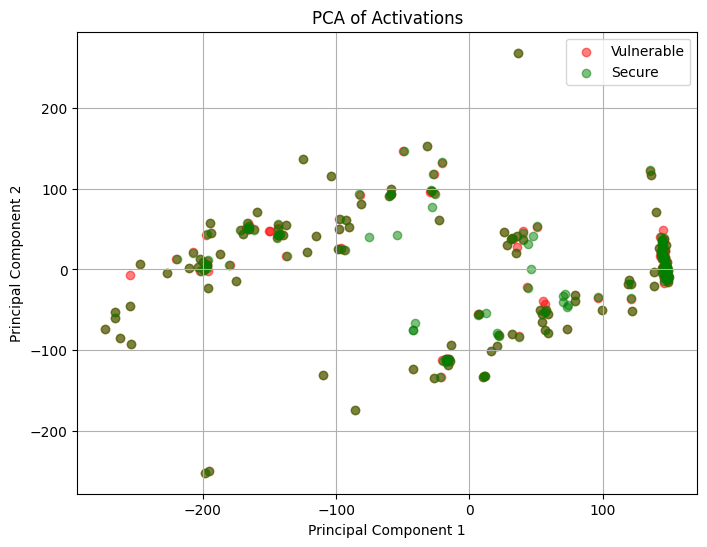

Layer: layer_1
Layer layer_1 - Probing Accuracy: 0.3025


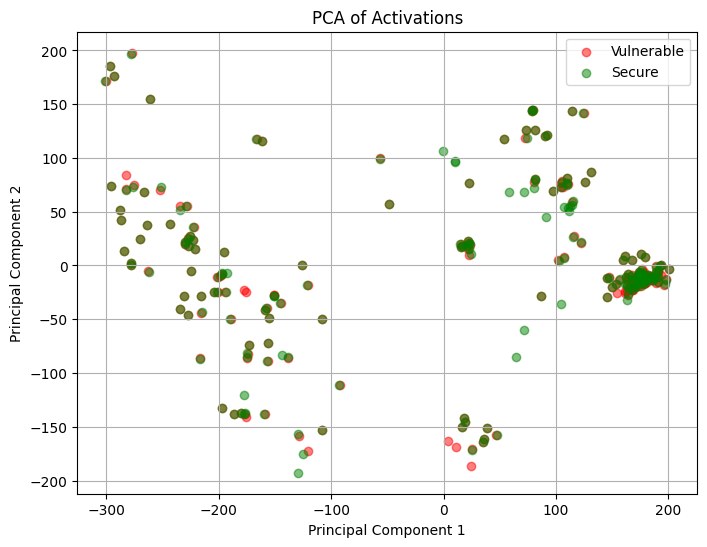

Layer: layer_2
Layer layer_2 - Probing Accuracy: 0.2875


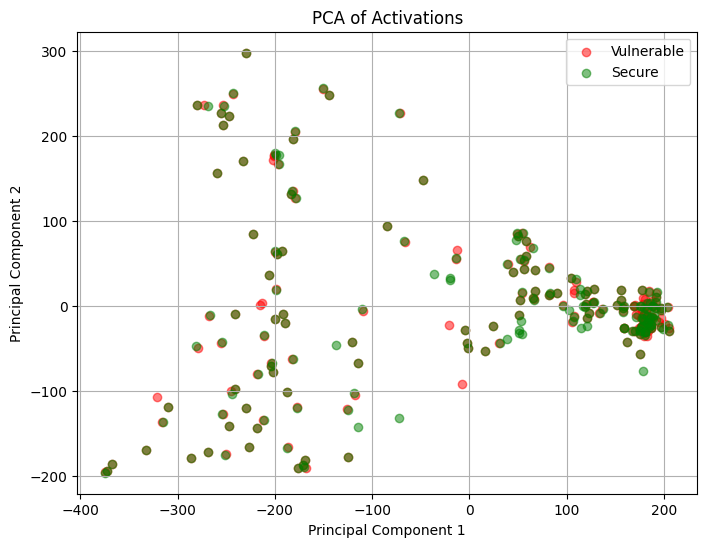

Layer: layer_3
Layer layer_3 - Probing Accuracy: 0.2575


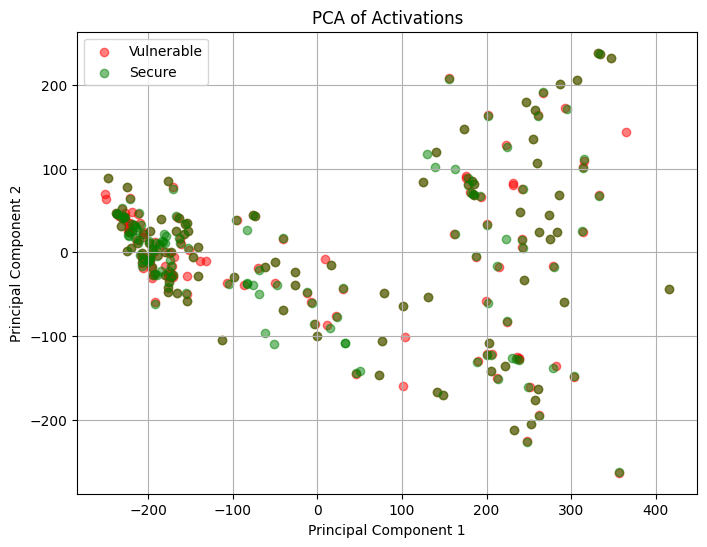

Layer: layer_4
Layer layer_4 - Probing Accuracy: 0.2150


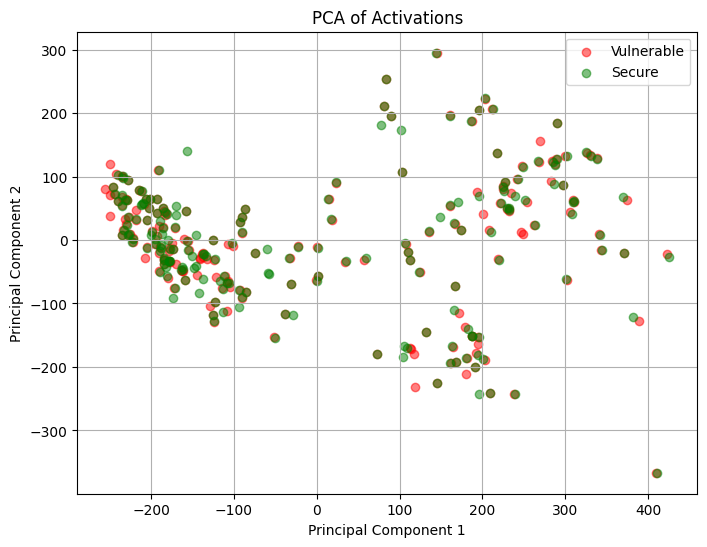

Layer: layer_5
Layer layer_5 - Probing Accuracy: 0.2275


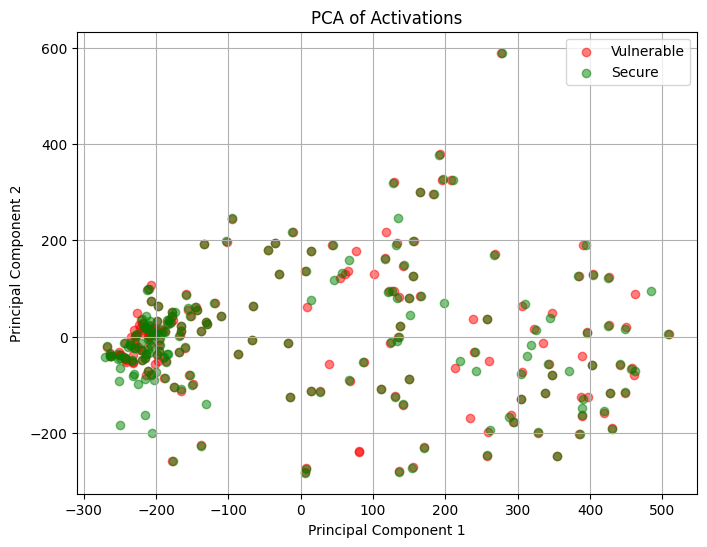

Layer: layer_6
Layer layer_6 - Probing Accuracy: 0.2000


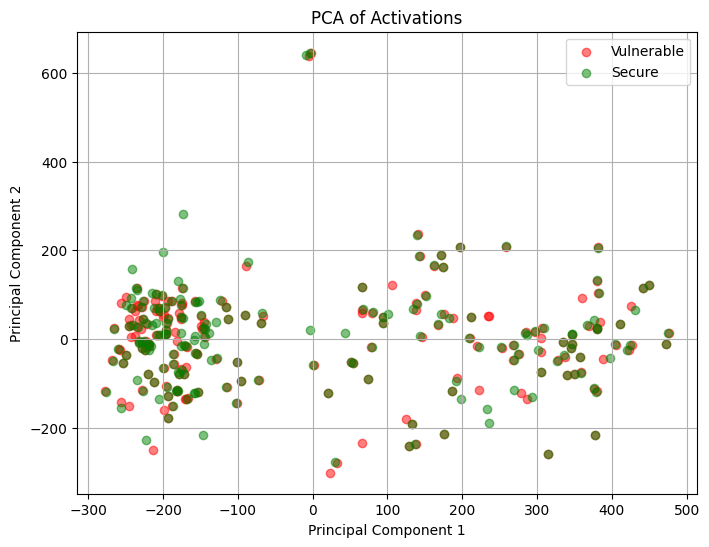

Layer: layer_7
Layer layer_7 - Probing Accuracy: 0.2125


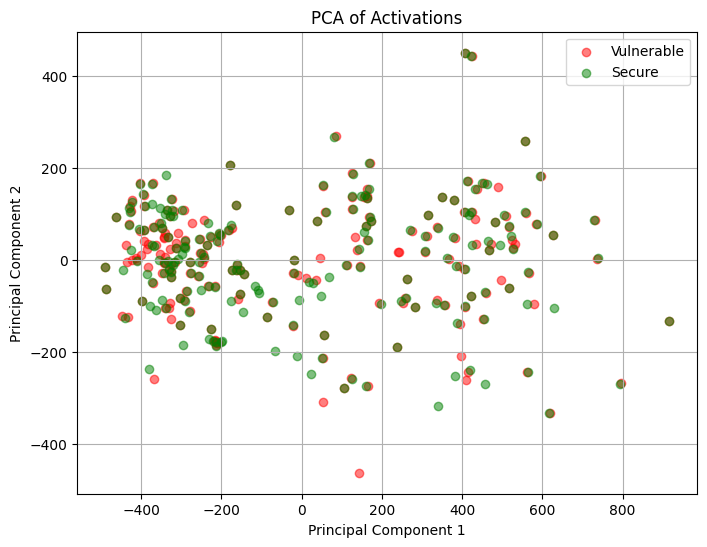

Layer: layer_8
Layer layer_8 - Probing Accuracy: 0.1925


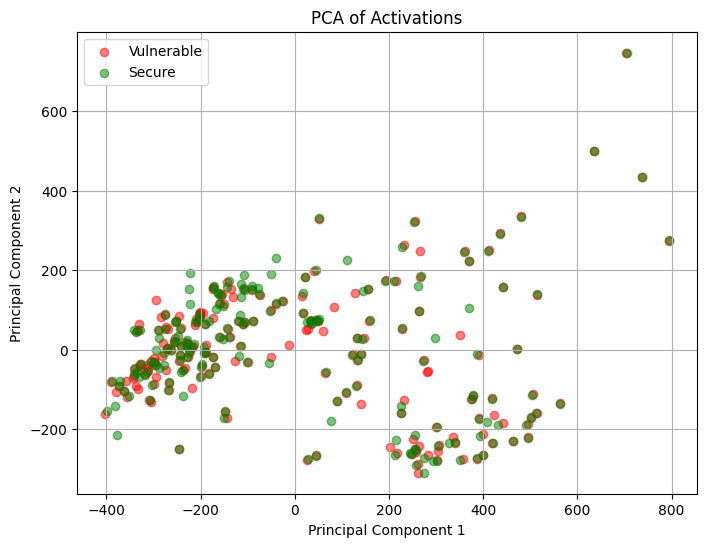

Layer: layer_9
Layer layer_9 - Probing Accuracy: 0.1850


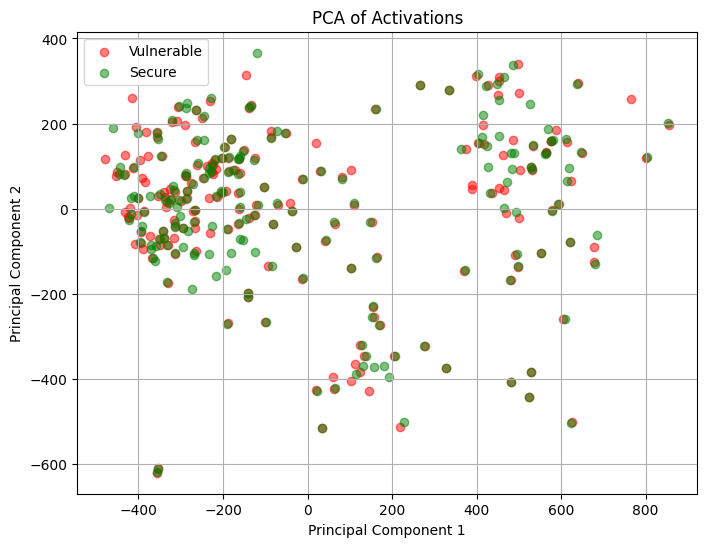

Layer: layer_10
Layer layer_10 - Probing Accuracy: 0.2075


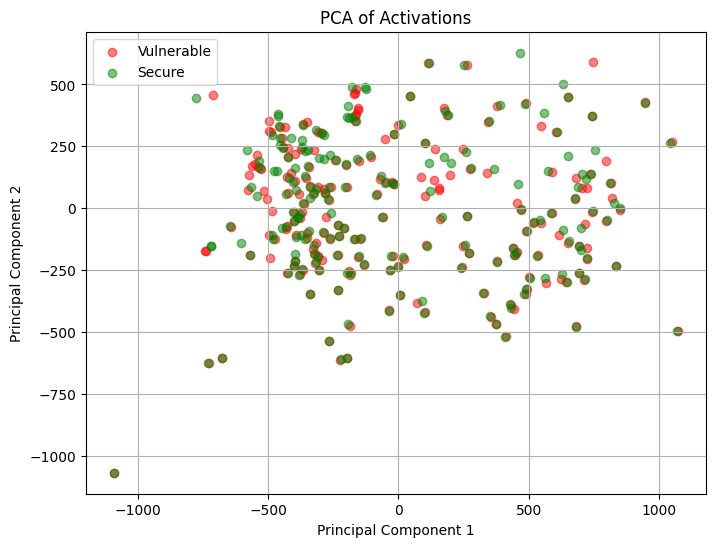

Layer: layer_11
Layer layer_11 - Probing Accuracy: 0.2200


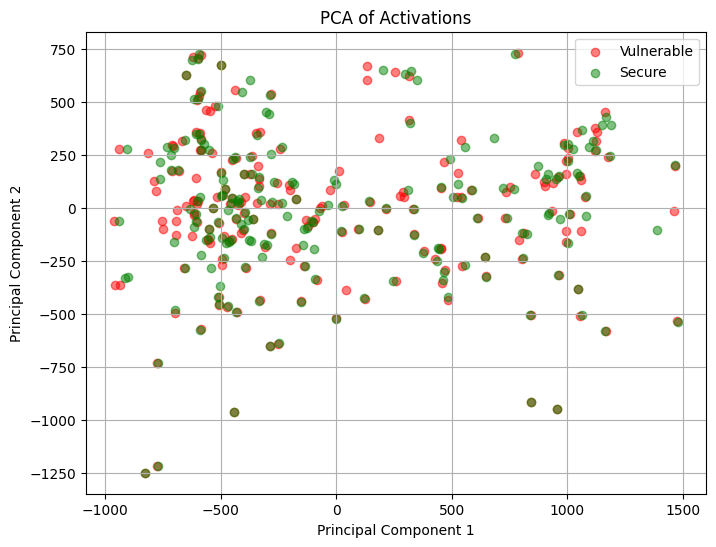

Layer: layer_12
Layer: layer_13
Layer: layer_14
Layer: layer_15
Layer: layer_16
Layer: layer_17
Layer: layer_18
Layer: layer_19
Layer: layer_20
Layer: layer_21
Layer: layer_22
Layer: layer_23
Layer: layer_24


In [27]:
for layer in all_safe_features.keys():
    print("Layer:", layer)
    if all_safe_features[layer].shape[0] != 0:
        acc = train_small_mlp_kfold( all_safe_features[layer], all_vulnerable_features[layer], k=5)
        print(f"Layer {layer} - Probing Accuracy: {acc:.4f}")
        plot_pca(
            all_safe_features[layer],
            all_vulnerable_features[layer],
        )

## Dump

In [ ]:
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

def plot_pca_subplots(cwe_data_map: Dict[str, VulnerabilityData]):
    """Create subplots for each CWE"""
    n_cwes = len(cwe_data_map)
    n_cols = 3
    n_rows = (n_cwes + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
    axes = axes.flatten() if n_cwes > 1 else [axes]
    
    for idx, (cwe, data) in enumerate(cwe_data_map.items()):
        pca = PCA(n_components=2)
        
        # Fit PCA on combined data
        combined_data = torch.cat([data.vulnerable, data.secure], dim=0).numpy()
        pca_transformed = pca.fit_transform(combined_data)
        
        # Split back into vulnerable and safe
        vuln_size = data.vulnerable.shape[0]
        vuln_pca = pca_transformed[:vuln_size]
        safe_pca = pca_transformed[vuln_size:]
        
        ax = axes[idx]
        ax.scatter(
            vuln_pca[:, 0],
            vuln_pca[:, 1],
            c="red",
            label="Vulnerable",
            alpha=0.7,
        )
        ax.scatter(
            safe_pca[:, 0],
            safe_pca[:, 1],
            c="blue",
            label="Safe",
            alpha=0.7,
        )
        ax.set_xlabel("PCA Component 1")
        ax.set_ylabel("PCA Component 2")
        ax.set_title(f"{cwe}")
        ax.legend()
    
    # Hide unused subplots
    for idx in range(n_cwes, len(axes)):
        axes[idx].axis('off')
    
    plt.suptitle("PCA of Sparse Autoencoder Activations by CWE", fontsize=16, y=1.00)
    plt.tight_layout()
    plt.show()


# Plot subplots for each CWE
print("Plotting PCA subplots for each CWE")
plot_pca_subplots(cwe_tensor_map)
